 # Simulación de válvulas — TAMI 2026 AySA                                     
                                                                                
Modelo de analogía eléctrico-hidráulica para el sistema de soplantes y válvulas del desarenador/desengrasador de la planta de AySA (Hurlingham). Leer informe para tener mas contexto.               
                                                                                
Se tienen en cuenta los siguientes supuestos:                                                        
  - Se trabaja únicamente con el Soplante 1, por lo que V2 = 9 fijo y V4 = 0.          
  - Se considera solamente configuraciones variando las las válvulas (V1, V3, V5)         
                                     
                                                                                


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from ipywidgets import interact, IntSlider

/home/ezequel/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


### Obtención de caudal para cierta configuración de válvulas y de configuraciones posibles dado cierto caudal 

Creamos dos estructuras que nos permiten obtener ambas cosas para el modelo del sistema mediante la analogía eléctrico-hidráulica. 

In [2]:


cv = 1.156*np.array([2.6, 23, 54, 94, 148, 237, 429, 606, 727])
R = []
for k in range(9):
    R.append(1/(cv[k]**2))
R = np.array(R)
A = np.zeros((4,9**3))

k=0
caudal_valvulas = {}
valvulas_caudal = {}
for v1 in range(9):
    for v3 in range(9):
        for v5 in range(9):
            caudal_fino =  (0.25*(R[v3]+R[v5]))/(0.29*R[v1]+0.25*(R[v3]+R[v5])) ## cuando antes estaba así (R[v3]+R[v5])/(R[v1]+R[v5]+R[v3])
            redondeo_fino = 0
            salto = 0.1
            saltos = np.linspace(0,100,int(100/salto)+1)
            for t in saltos: 
                if t <= caudal_fino*100  < t + salto:
                    redondeo_fino = t
            #diccionario / (v1,v3,v5) --> redondeo fino que se puede obtener para esas valvulas 
            valvulas_caudal[(v1+1,v3+1,v5+1)] = redondeo_fino
            A[:,k] = np.array([v1+1,v3+1,v5+1,redondeo_fino])
            #diccionario / redondeo fino --> (v1,v3,v5) tales que me da ese redondeo fino 
            if int(redondeo_fino*100) in caudal_valvulas:
                #si ya esta definida agrego otra mas a la lista
                caudal_valvulas[int(redondeo_fino*100)].append((v1+1,v3+1,v5+1))
            else:
                #si nunca estuvo definida entonces defino el significado como una lista que solo tenga a la tripla 
                caudal_valvulas[int(redondeo_fino*100)] = [(v1+1,v3+1,v5+1)]
            k += 1

print(valvulas_caudal[8,7,7]) #los grupos van de 0 a 98 (o a 95), no hay grupo "100"



77.4


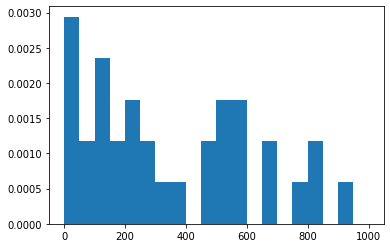

In [3]:
lista_caudales = list(caudal_valvulas.keys())
histograma = plt.hist(x=lista_caudales,bins=20,range=(0,1000),density=True)

In [4]:
contador = 0
for caudal in caudal_valvulas:
    if caudal >= 999:
        contador += len(caudal_valvulas[caudal])
print(contador)

600


# Planear un experimento dado un caudal buscado
Para pensar distintos experimentos se puede recorrer los dos diccionarios anteriores para buscar la configuración que tiene el caudal mas cercano a un valor buscado.

In [5]:
def obtener_configuracion(caudal):
    cercano_buscado = min(k for k in caudal_valvulas if k >= caudal)
    print("el caudal posible mas cercano es", cercano_buscado, "y las configuraciones posibles son ")
    for c in caudal_valvulas[cercano_buscado]: 
        print(c, " ")

obtener_configuracion(9990)


valvulas_caudal[7,6,2]
caudal_valvulas[9980]




el caudal posible mas cercano es 9990 y las configuraciones posibles son 
(4, 1, 1)  
(4, 1, 2)  
(4, 1, 3)  
(4, 1, 4)  
(4, 1, 5)  
(4, 1, 6)  
(4, 1, 7)  
(4, 1, 8)  
(4, 1, 9)  
(4, 2, 1)  
(4, 3, 1)  
(4, 4, 1)  
(4, 5, 1)  
(4, 6, 1)  
(4, 7, 1)  
(4, 8, 1)  
(4, 9, 1)  
(5, 1, 1)  
(5, 1, 2)  
(5, 1, 3)  
(5, 1, 4)  
(5, 1, 5)  
(5, 1, 6)  
(5, 1, 7)  
(5, 1, 8)  
(5, 1, 9)  
(5, 2, 1)  
(5, 3, 1)  
(5, 4, 1)  
(5, 5, 1)  
(5, 6, 1)  
(5, 7, 1)  
(5, 8, 1)  
(5, 9, 1)  
(6, 1, 1)  
(6, 1, 2)  
(6, 1, 3)  
(6, 1, 4)  
(6, 1, 5)  
(6, 1, 6)  
(6, 1, 7)  
(6, 1, 8)  
(6, 1, 9)  
(6, 2, 1)  
(6, 3, 1)  
(6, 4, 1)  
(6, 5, 1)  
(6, 6, 1)  
(6, 7, 1)  
(6, 8, 1)  
(6, 9, 1)  
(7, 1, 1)  
(7, 1, 2)  
(7, 1, 3)  
(7, 1, 4)  
(7, 1, 5)  
(7, 1, 6)  
(7, 1, 7)  
(7, 1, 8)  
(7, 1, 9)  
(7, 2, 1)  
(7, 3, 1)  
(7, 4, 1)  
(7, 5, 1)  
(7, 6, 1)  
(7, 7, 1)  
(7, 8, 1)  
(7, 9, 1)  
(8, 1, 1)  
(8, 1, 2)  
(8, 1, 3)  
(8, 1, 4)  
(8, 1, 5)  
(8, 1, 6)  
(8, 1, 7)  
(8, 1, 8)  
(8, 1, 9)  
(8

[(3, 1, 1),
 (7, 2, 2),
 (8, 2, 3),
 (8, 2, 4),
 (8, 2, 5),
 (8, 2, 6),
 (8, 2, 7),
 (8, 2, 8),
 (8, 2, 9),
 (8, 3, 2),
 (8, 4, 2),
 (8, 5, 2),
 (8, 6, 2),
 (8, 7, 2),
 (8, 8, 2),
 (8, 9, 2),
 (9, 2, 4),
 (9, 2, 5),
 (9, 2, 6),
 (9, 2, 7),
 (9, 2, 8),
 (9, 2, 9),
 (9, 4, 2),
 (9, 5, 2),
 (9, 6, 2),
 (9, 7, 2),
 (9, 8, 2),
 (9, 9, 2)]

# Explorar configuraciones de v1, v3 y v5 de forma visual

Armamos una grilla que para toda combinación posible de v1 y v5 calcule su caudal tomando v3 como un valor que se puede 

In [6]:
matriz = np.zeros((9,9))
v3_deseado = 9
for (v1, v3, v5), caudal in valvulas_caudal.items(): 
    matriz[v1-1][v5-1] = valvulas_caudal[v1,v3_deseado,v5]



In [7]:

#generar grilla para un v3 fijo 
def graficar_caudal(v3_deseado):
    
    matriz = np.zeros((9, 9))
    
    for v1 in range(1, 10):
        for v5 in range(1, 10):
            matriz[v1-1, v5-1] = valvulas_caudal[v1, v3_deseado, v5]
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(matriz, 
                annot=True,         
                fmt=".1f",           
                cmap="YlGnBu",      
                xticklabels=range(1, 10), 
                yticklabels=range(1, 10),
                cbar_kws={'label': ' proporción de caudal fino'})
    
    plt.title(f'Nivel de apertura para v3 = {v3_deseado}', fontsize=15)
    plt.xlabel('V5)')
    plt.ylabel('V1')
    plt.show()


interact(graficar_caudal, v3_deseado=IntSlider(min=1, max=9, step=1, value=3))

interactive(children=(IntSlider(value=3, description='v3_deseado', max=9, min=1), Output()), _dom_classes=('wi…

<function __main__.graficar_caudal(v3_deseado)>

# Otra forma de ver esto

Teniendo en cuenta todas las combinaciones cambiando las valvulas entre 1 y 9, vemos cómo se agrupan estas según los valores que tienen para cada valvula

Son  729  configuraciones


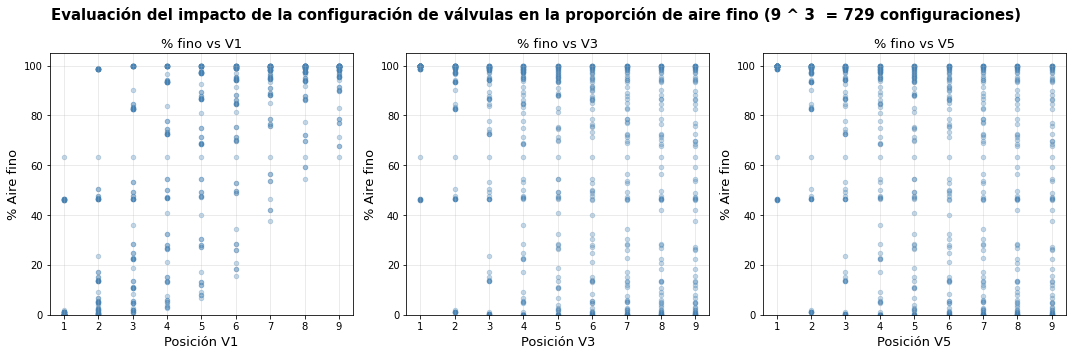

In [8]:
def obtener_fino(v1, v3, v5):                                                                                                                                                                                                                                                                                                                                                                                      
    return valvulas_caudal[v1,v3,v5]




configuraciones = [(v1, v3, v5) for v1 in range(1,10) for v3 in range(1,10) for v5 in range(1,10)]
finos   = [obtener_fino(v1, v3, v5) for v1, v3, v5 in configuraciones]                                                                                                                                                           
                
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, idx, label in zip(axes, [0, 1, 2], ['V1', 'V3', 'V5']):
    x = [c[idx] for c in configuraciones]
    ax.scatter(x, finos, alpha=0.3, s=20, color='steelblue')
    ax.set_xlabel(f'Posición {label}', fontsize=13)
    ax.set_ylabel('% Aire fino', fontsize=13)
    ax.set_title(f'% fino vs {label}', fontsize=13)
    ax.set_ylim(0, 105)
    ax.set_xticks(range(1, 10))
    ax.grid(alpha=0.3)
print("Son ", len(configuraciones), " configuraciones")
plt.suptitle('Evaluación del impacto de la configuración de válvulas en la proporción de aire fino (9 ^ 3  = 729 configuraciones)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('scatter_valvulas_fijas.jpg', dpi=150, bbox_inches='tight')                                                                                                                                                   

 #pareciera que mover v3 y v5 no cambia significativamente mucho? 
 #si esto es así, sería posible con v1 explorar tres experimentos significativamente diferentes dejando fijas solo las otras dos valvulas? 


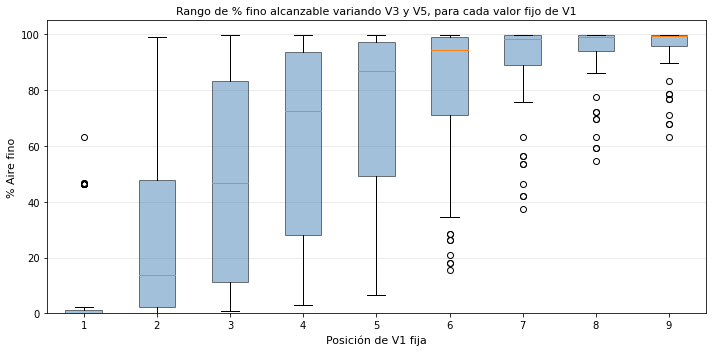

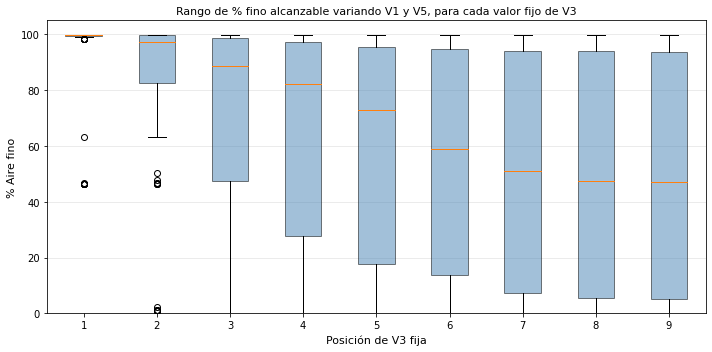

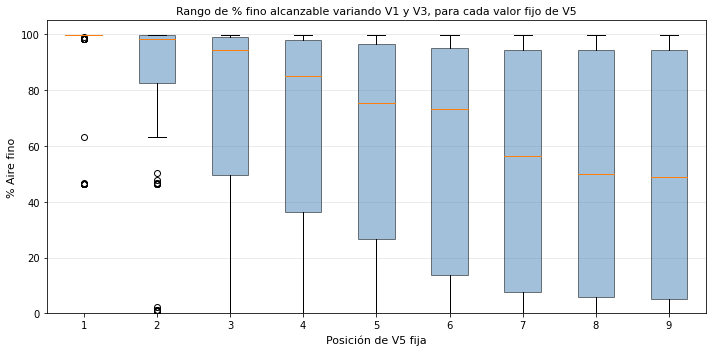

In [9]:
                
fig, ax = plt.subplots(figsize=(10, 5))                                                                                                                                                                          
                
datos_por_v1 = [
    [obtener_fino(v1, v3, v5) for v3 in range(1,10) for v5 in range(1,10)]
    for v1 in range(1, 10)
]

ax.boxplot(datos_por_v1, labels=range(1, 10), patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.5))

ax.set_xlabel('Posición de V1 fija', fontsize=11)
ax.set_ylabel('% Aire fino', fontsize=11)
ax.set_title('Rango de % fino alcanzable variando V3 y V5, para cada valor fijo de V1', fontsize=11)
ax.set_ylim(0, 105)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('boxplot_v1_fijo.jpg', dpi=150, bbox_inches='tight')                                                                                                                                                   

plt.show()

fig, ax = plt.subplots(figsize=(10, 5))                                                                                                                                                                          
                
datos_por_v1 = [
    [obtener_fino(v1, v3, v5) for v1 in range(1,9) for v5 in range(1,9)]
    for v3 in range(1, 10)
]

ax.boxplot(datos_por_v1, labels=range(1, 10), patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.5))

ax.set_xlabel('Posición de V3 fija', fontsize=11)
ax.set_ylabel('% Aire fino', fontsize=11)
ax.set_title('Rango de % fino alcanzable variando V1 y V5, para cada valor fijo de V3', fontsize=11)
ax.set_ylim(0, 105)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('boxplot_v3_fijo.jpg', dpi=150, bbox_inches='tight')                                                                                                                                                   

plt.show()

fig, ax = plt.subplots(figsize=(10, 5))                                                                                                                                                                          
                
datos_por_v1 = [
    [obtener_fino(v1, v3, v5) for v1 in range(1,10) for v3 in range(1,10)]
    for v5 in range(1, 10)
]

ax.boxplot(datos_por_v1, labels=range(1, 10), patch_artist=True,
            boxprops=dict(facecolor='steelblue', alpha=0.5))

ax.set_xlabel('Posición de V5 fija', fontsize=11)
ax.set_ylabel('% Aire fino', fontsize=11)
ax.set_title('Rango de % fino alcanzable variando V1 y V3, para cada valor fijo de V5', fontsize=11)
ax.set_ylim(0, 105)
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('boxplot_v5_fijo.jpg', dpi=150, bbox_inches='tight')                                                                                                                                                   

plt.show()

